# Modulo de software que permite a los usuarios generar y comparar trayectorias para un brazo robótico

## Para el módulo se usaran dos enfoques.
### Enfoque 1: Curvas de Bézier recursivo: Una curva de Bézier usa puntos de control para construir una curva suave.

### ¿Como funciona?
El algoritmo toma puntos y hace interpolaciones lineales entre ellos.

Ejemplo:
P0, P1, P2

1. Interpolaciones entre P0 y P1
2. Interpolaciones entre P1 y P2
3. Interpolaciones entre los resultados anteriores.

*Dichos pasos se hacen recursivamente*

Para elaborar el algoritmo recursivo, se usan los siguientes casos:

- Caso Base:
Si solo hay 1 punto, ese es el resultado.

- Caso recursivo:
Interpolar puntos consecutivos.
LLamar a la función otra vez con esos nuevos puntos.

### Librerías necesarias

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

### Función auxiliar para interpolar 2 puntos

In [5]:
def interpolar(p0, p1, t):
    px = ((1-t)*p0[0]) + (t*p1[0])
    py = ((1-t)*p0[1]) + (t*p1[1])
    return (px, py)

### Algoritmo Bezier recursivo

In [6]:
def bezierRecursivo(puntos, t):
    if len(puntos) == 1:
        return puntos[0]
    
    puntosNuevos = []
    for i in range(len(puntos)-1):
        puntosNuevos.append(interpolar(puntos[i], puntos[i+1], t))
        
    return bezierRecursivo(puntosNuevos, t)

### Generador de trayectoria

In [12]:
def generarTrayectoria(puntos, pasos):
    trayectoria = []

    for i in range(pasos+1):
        t = i / pasos
        punto = bezierRecursivo(puntos, t)
        trayectoria.append(punto)
        
    return trayectoria

### Test

[(0.0, 0.0), (1.0, 2.88), (2.0000000000000004, 3.8400000000000007), (3.0, 3.3599999999999985), (4.0, 1.92), (5.0, 0.0), (6.0, -1.92), (7.0, -3.36), (8.0, -3.84), (9.0, -2.8799999999999994), (10.0, 0.0)]


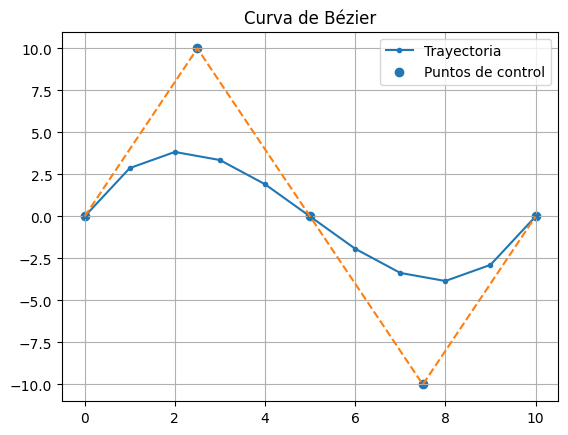

In [ ]:
puntos = [(0, 0), (2.5, 10), (5, 0),(7.5,-10),(10, 0)]
trayectoria = generarTrayectoria(puntos, 10)
print(trayectoria)

x_control = [p[0] for p in puntos]
y_control = [p[1] for p in puntos]

x_tray = [p[0] for p in trayectoria]
y_tray = [p[1] for p in trayectoria]

plt.figure()
plt.plot(x_tray, y_tray, marker='.', label='Trayectoria')
plt.scatter(x_control, y_control, label='Puntos de control')
plt.plot(x_control, y_control, linestyle='--')
plt.title("Curva de Bézier")
plt.legend()
plt.grid()
plt.show()